# Imports

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
df = pd.read_csv("../datasets/raw/IndianWeatherRepository.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# Numerical Feature List

In [2]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns
print("Numerical Features:", len(numerical_columns))
numerical_columns

Numerical Features: 30


Index(['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius', 'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in',
       'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'moon_illumination'],
      dtype='str')

# Distribution Analysis Function

In [3]:
def plot_distribution(column):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.histplot(
        df[column],
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribution of {column}")
    sns.boxplot(
        x=df[column],
        ax=axes[1]
    )
    axes[1].set_title(f"Boxplot of {column}")
    plt.tight_layout()
    plt.show()

# Temperature Distribution

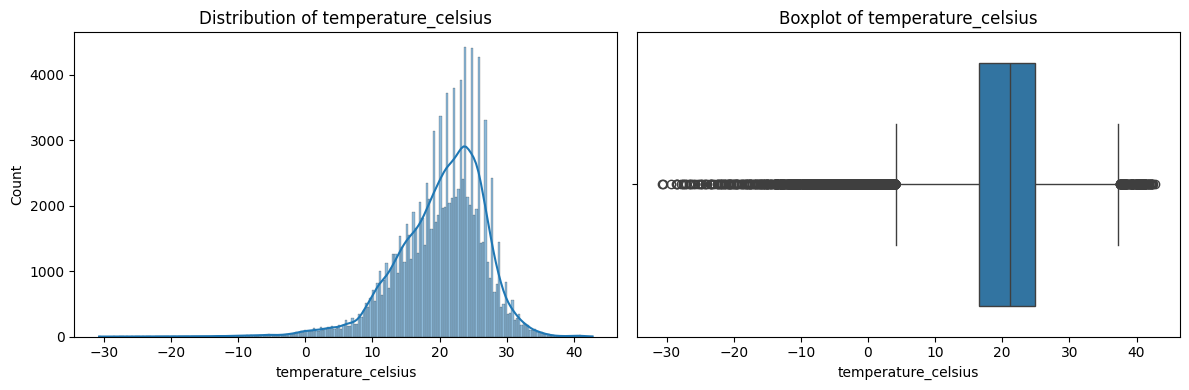


Temperature ranges from -30.7°C to 42.8°C.
Most observations are concentrated
between 15°C and 30°C.
Suitable for heatwave modeling.



In [4]:
plot_distribution("temperature_celsius")

# Insight:

print("""
Temperature ranges from -30.7°C to 42.8°C.
Most observations are concentrated
between 15°C and 30°C.
Suitable for heatwave modeling.
""")

# Humidity Distribution

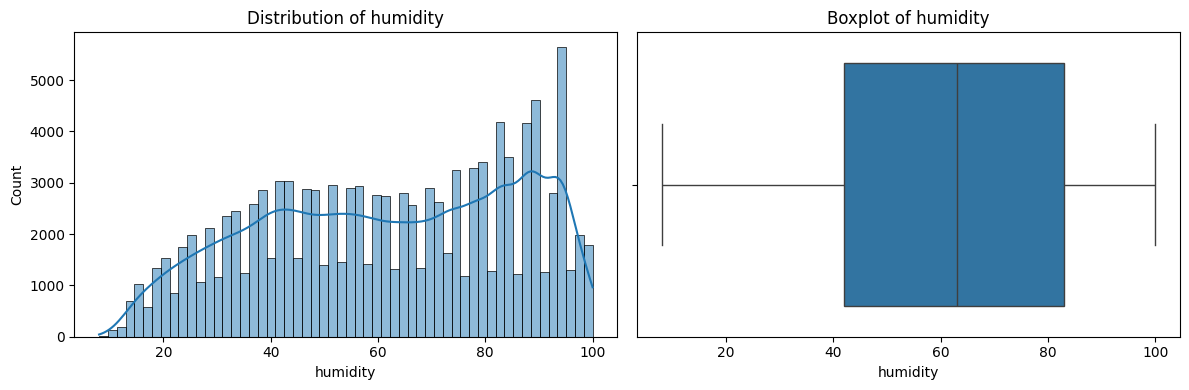


Humidity varies widely.
Most observations fall between
40% and 85%.
Useful predictor for rainfall risk.



In [5]:
plot_distribution("humidity")

# Insight:

print("""
Humidity varies widely.
Most observations fall between
40% and 85%.
Useful predictor for rainfall risk.
""")

# Precipitation Distribution

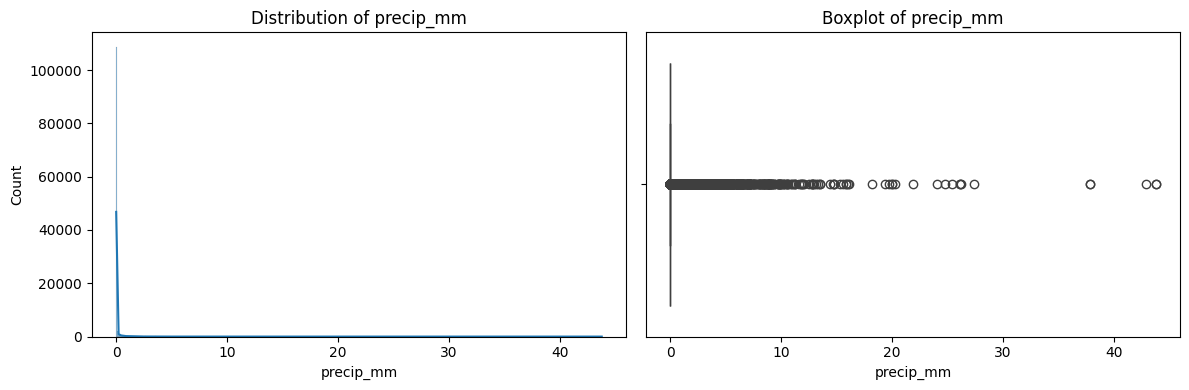


Rainfall is highly right-skewed.
Most observations contain
little or no rainfall.
Class imbalance is expected
for rainfall prediction.



In [6]:
plot_distribution("precip_mm")

# Insight:
print("""
Rainfall is highly right-skewed.
Most observations contain
little or no rainfall.
Class imbalance is expected
for rainfall prediction.
""")

# Pressure Distribution

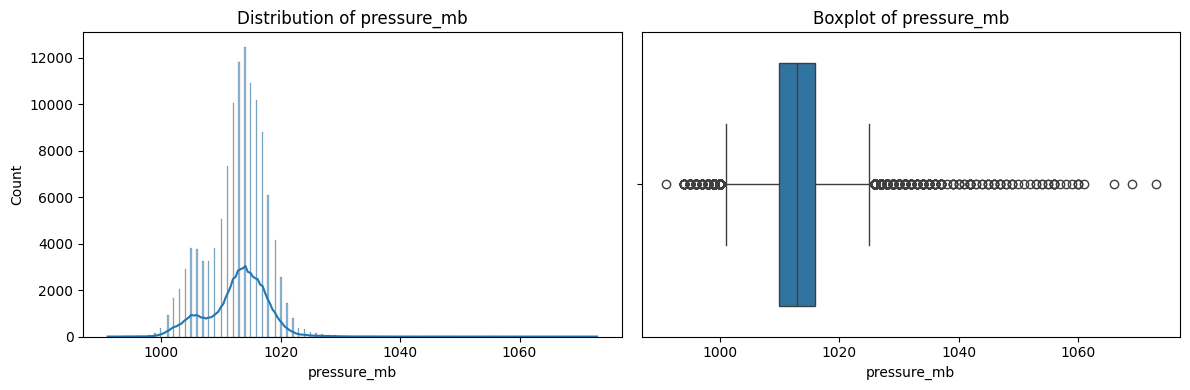


Pressure values are concentrated
around normal atmospheric levels.
Low pressure observations may
indicate rainfall events.



In [7]:
plot_distribution("pressure_mb")

# Insight:

print("""
Pressure values are concentrated
around normal atmospheric levels.
Low pressure observations may
indicate rainfall events.
""")

# Wind Speed Distribution

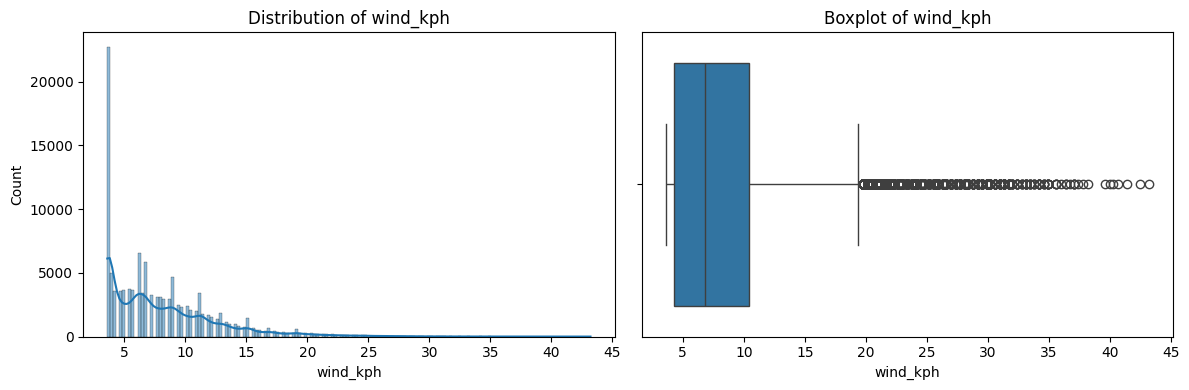


Most wind speeds are moderate.
Extreme wind conditions are rare.



In [24]:
plot_distribution("wind_kph")

# Insight:

print("""
Most wind speeds are moderate.
Extreme wind conditions are rare.
""")

# Visibility Distribution

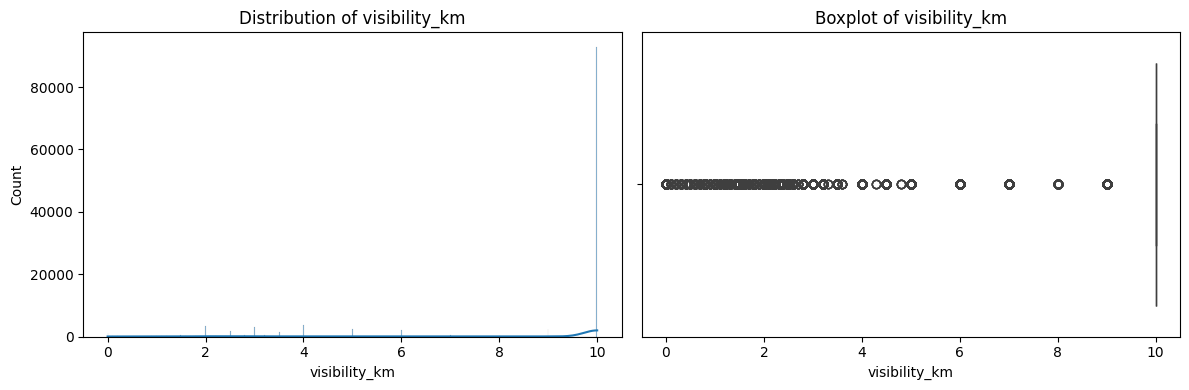


Visibility is concentrated
around 10 km.
Feature may exhibit low variance.



In [9]:
plot_distribution("visibility_km")

# Insight:

print("""
Visibility is concentrated
around 10 km.
Feature may exhibit low variance.
""")

# UV Index Distribution

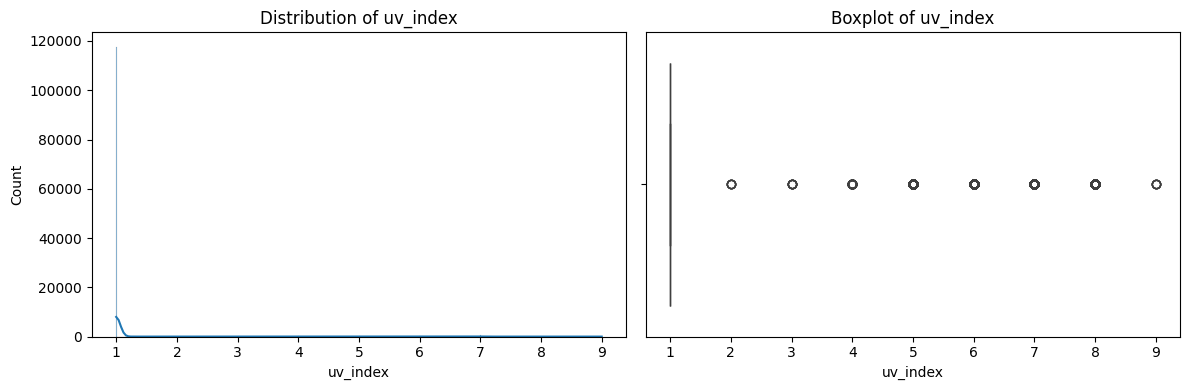


UV index values are generally low.

High UV values may contribute
to heatwave conditions.



In [10]:
plot_distribution("uv_index")

# Insight:

print("""
UV index values are generally low.

High UV values may contribute
to heatwave conditions.
""")

# PM2.5 Distribution

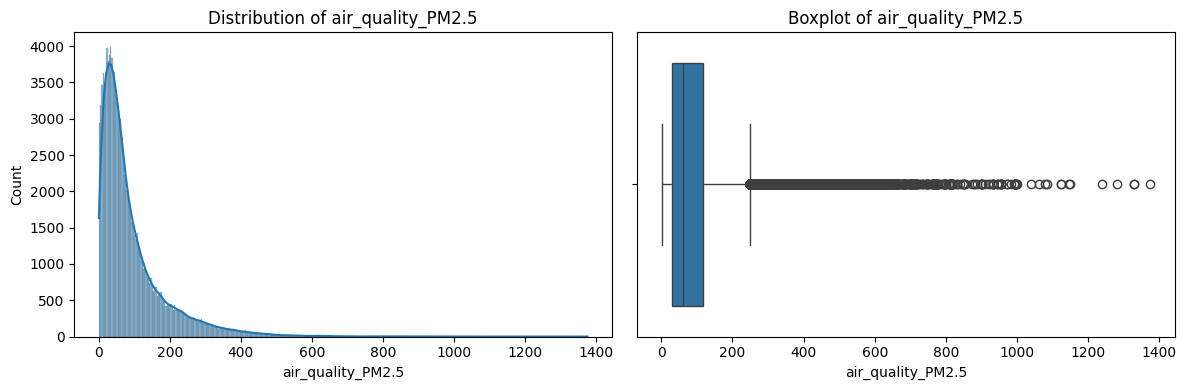


PM2.5 exhibits significant skewness.
Extreme pollution observations exist.
Important for anomaly detection.



In [11]:
plot_distribution("air_quality_PM2.5")

# Insight:

print("""
PM2.5 exhibits significant skewness.
Extreme pollution observations exist.
Important for anomaly detection.
""")

# PM10 Distribution

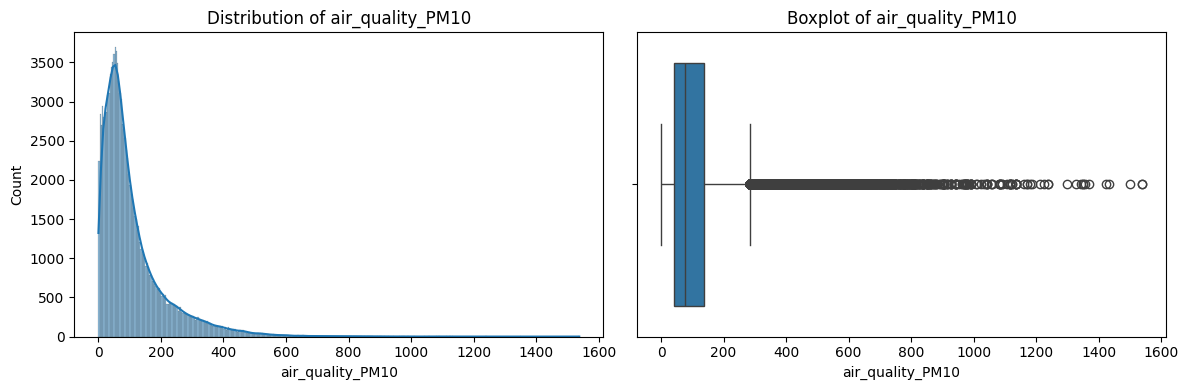


PM10 contains large outliers.
Useful for pollution profile discovery.



In [12]:
plot_distribution("air_quality_PM10")

# Insight:

print("""
PM10 contains large outliers.
Useful for pollution profile discovery.
""")

# Carbon Monoxide Distribution

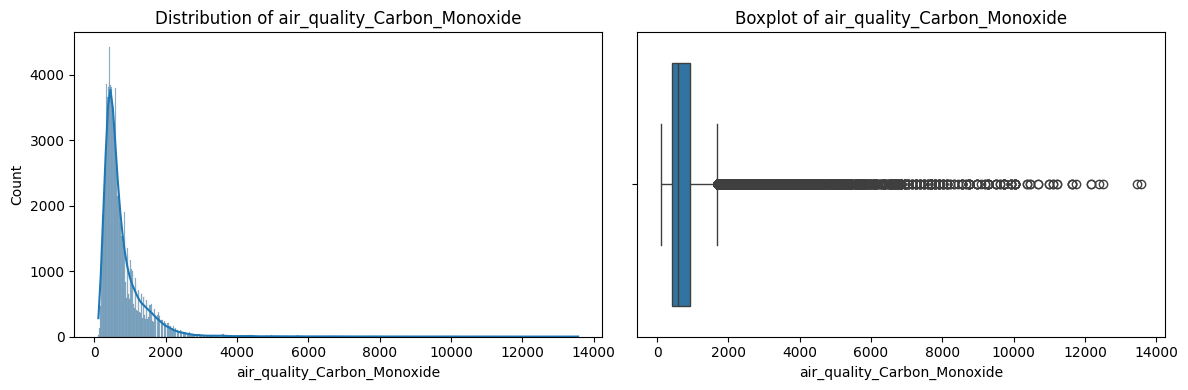

In [13]:
plot_distribution("air_quality_Carbon_Monoxide")

# Ozone Distribution

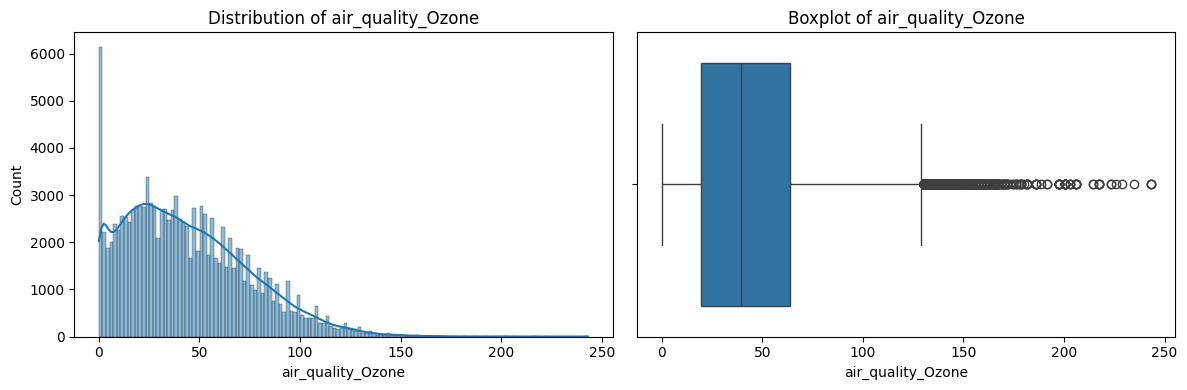

In [14]:
plot_distribution("air_quality_Ozone")

# Nitrogen Dioxide Distribution

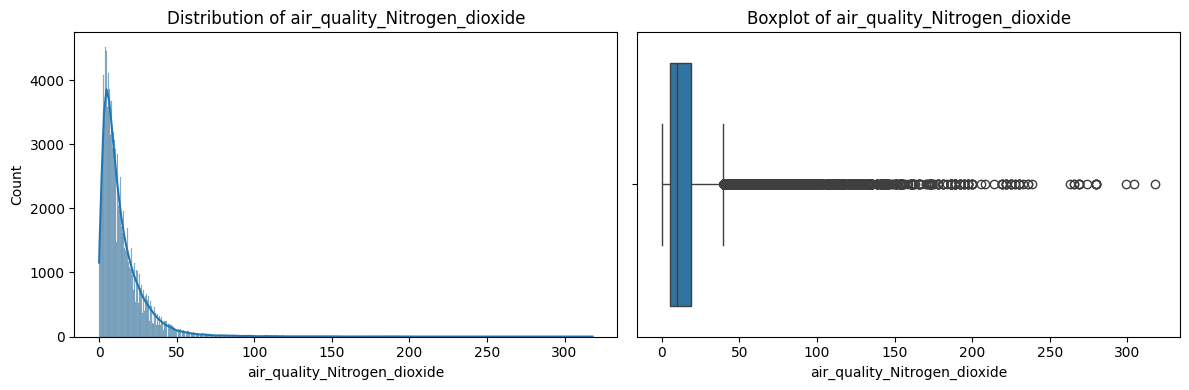

In [15]:
plot_distribution("air_quality_Nitrogen_dioxide")

# Sulphur Dioxide Distribution

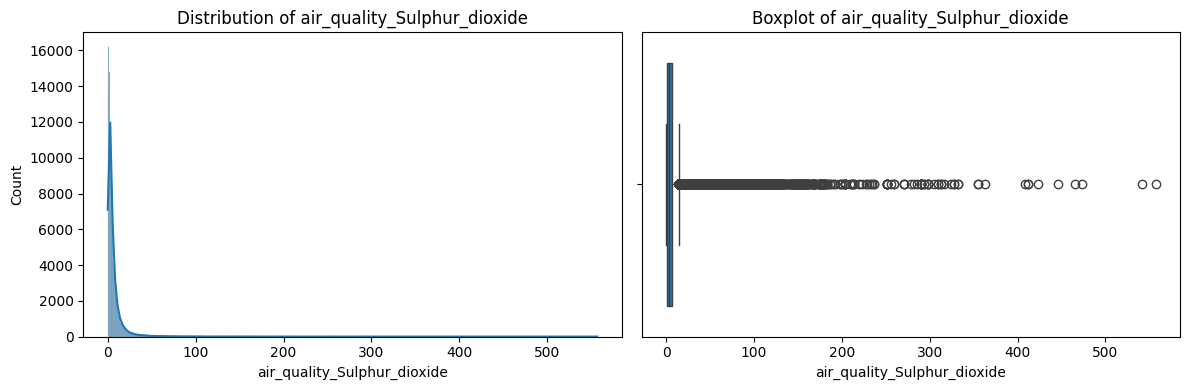

In [16]:
plot_distribution("air_quality_Sulphur_dioxide")

# Categorical Feature List

## Categorical Feature List

In [17]:
categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns
print("Categorical Features:", len(categorical_columns))
categorical_columns

Categorical Features: 12


Index(['country', 'location_name', 'region', 'timezone', 'last_updated', 'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase'], dtype='str')

## Weather Condition Frequency 

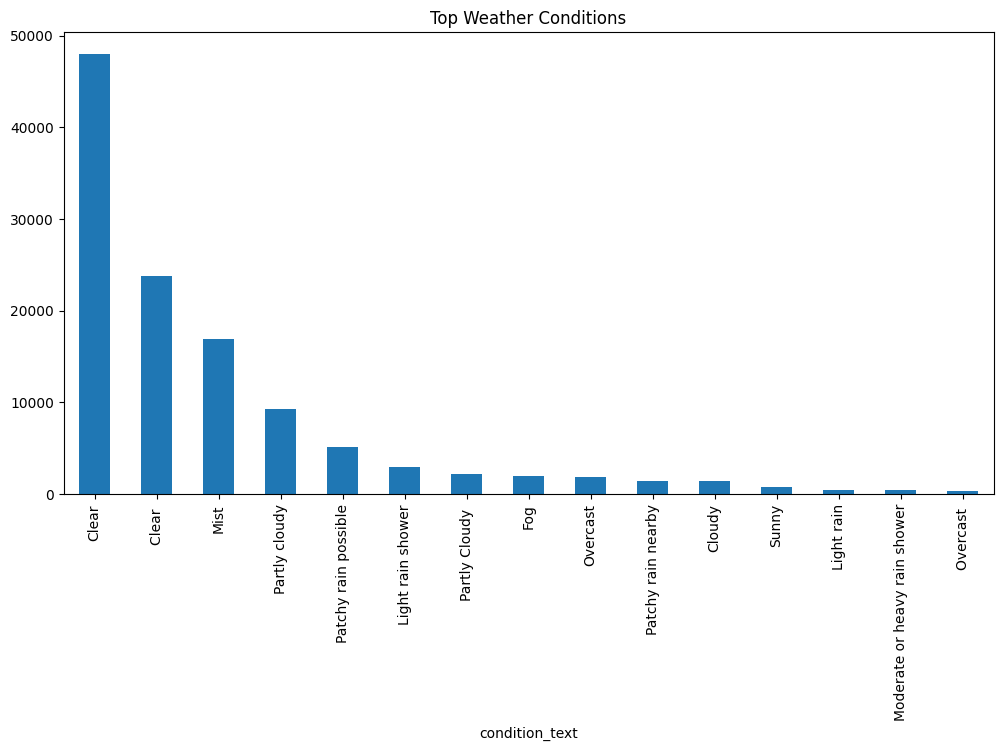


Clear weather dominates
the dataset.
Weather conditions show
significant diversity.



In [18]:
plt.figure(figsize=(12,6))
df["condition_text"].value_counts().head(15).plot(
    kind="bar"
)
plt.title("Top Weather Conditions")
plt.show()

# Insight:

print("""
Clear weather dominates
the dataset.
Weather conditions show
significant diversity.
""")

## Region Distribution 

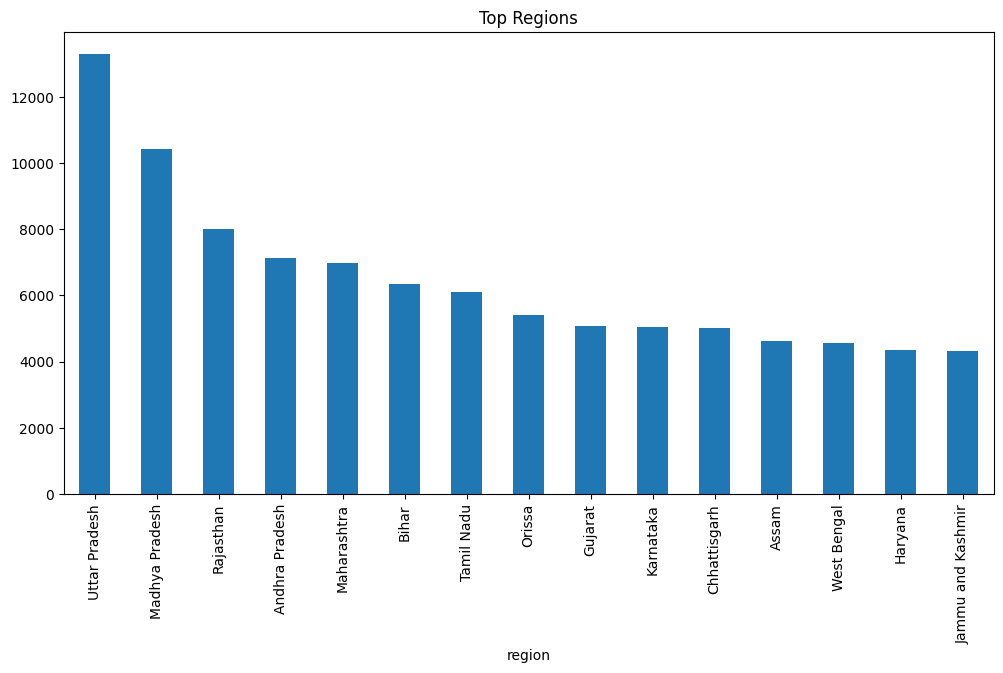

In [19]:
plt.figure(figsize=(12,6))
df["region"].value_counts().head(15).plot(
    kind="bar"
)
plt.title("Top Regions")
plt.show()

## Wind Direction Distribution 

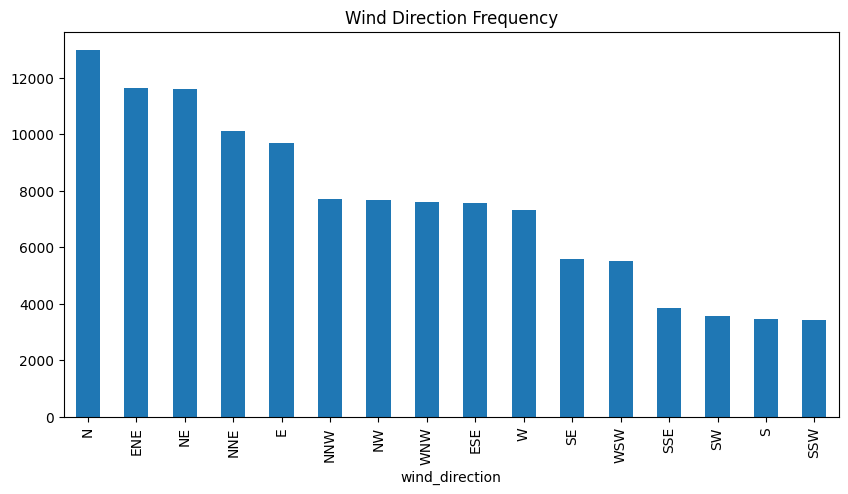

In [20]:
plt.figure(figsize=(10,5))
df["wind_direction"].value_counts().plot(
    kind="bar"
)
plt.title("Wind Direction Frequency")
plt.show()

## Moon Phase Distribution

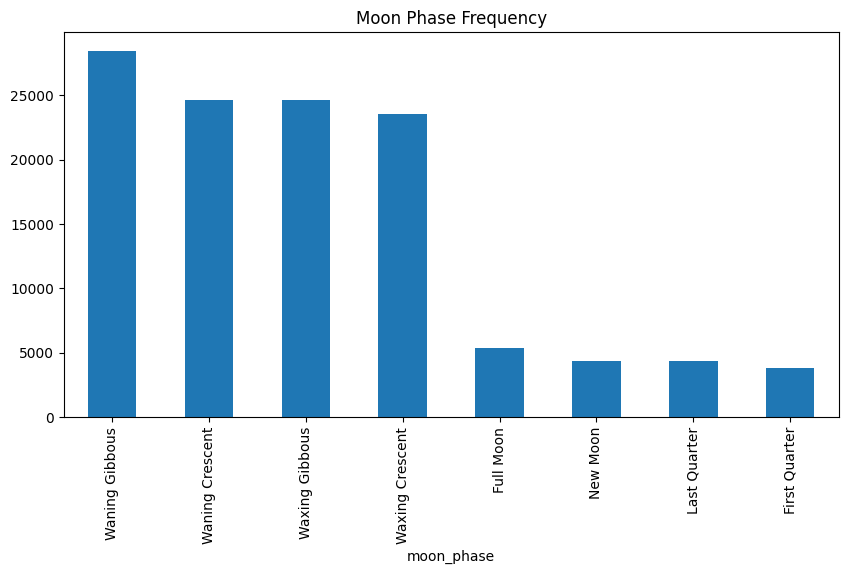

In [21]:
plt.figure(figsize=(10,5))
df["moon_phase"].value_counts().plot(
    kind="bar"
)
plt.title("Moon Phase Frequency")
plt.show()

# Outlier Summary

In [22]:
outlier_features = [
    "temperature_celsius",
    "precip_mm",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Carbon_Monoxide"
]
for col in outlier_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]
    print(col, ":", outliers)
    

temperature_celsius : 2640
precip_mm : 14888
air_quality_PM2.5 : 8805
air_quality_PM10 : 8780
air_quality_Carbon_Monoxide : 7928


# C2 Insights Report 

In [23]:
print("""
UNIVARIATE ANALYSIS REPORT
1. Temperature shows wide variation.
2. Humidity spans a broad range.
3. Rainfall is highly skewed.
4. Visibility exhibits low variance.
5. PM2.5 and PM10 contain significant outliers.
6. Air quality features show heavy skewness.
7. Weather conditions are diverse.
8. Clear weather dominates observations.
9. Wind directions are well distributed.
10. Dataset contains several non-normal distributions.
11. Log transformation may be useful
for pollution and rainfall features.
12. Dataset is suitable for:
   - Climate Profiling
   - Anomaly Detection
   - Rainfall Prediction
   - Heatwave Prediction
""")



UNIVARIATE ANALYSIS REPORT
1. Temperature shows wide variation.
2. Humidity spans a broad range.
3. Rainfall is highly skewed.
4. Visibility exhibits low variance.
5. PM2.5 and PM10 contain significant outliers.
6. Air quality features show heavy skewness.
7. Weather conditions are diverse.
8. Clear weather dominates observations.
9. Wind directions are well distributed.
10. Dataset contains several non-normal distributions.
11. Log transformation may be useful
for pollution and rainfall features.
12. Dataset is suitable for:
   - Climate Profiling
   - Anomaly Detection
   - Rainfall Prediction
   - Heatwave Prediction

